### Convert model to TFLite INT8

#### Pipeline Overview
* best.py (float32):
    * step 1: Magnitude pruning -- structured sparsity on Conv layers // target: 20% 
    * step 2: Fine-tune (optional, 5 epochs) -- recover accuracy after pruning
    * step 3: Export to TFLite float16 -> best_fp16.tflite
    * step 4: Post-Training INT8 Quantization -> best_int8.tflite

* **requirement:** 
    * INT8 mAP@50 must stay within 3 point of float32 baseline (>= 0.907)
    * Model size must be <= 10 MB
    * Single-frame latency <= 5s on Pi 3B

In [2]:
import sys, os, copy, random, time, shutil, subprocess, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import tensorflow as tf
from PIL import Image
import yaml
warnings.filterwarnings('ignore')

In [3]:
# Env variable 

# Project paths
PROJECT_ROOT = Path.cwd().parent
YOLOV5_DIR= PROJECT_ROOT / 'model' / 'yolov5'
WEIGHTS_PT = PROJECT_ROOT / 'model' / 'train' / 'edge_cctv_v2' / 'weights' / 'best.pt'
TRAIN_WEIGHTS_DIR = WEIGHTS_PT.parent   # model/train/edge_cctv_v2/weights/ — already exists
SAVE_PLOTS_DIR = PROJECT_ROOT / 'plots'

EXPORT_DIR= PROJECT_ROOT / 'model' / 'train' / 'edge_cctv_v2' / 'export'
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)

SAVED_MODEL_DIR = EXPORT_DIR / 'saved_model'
TEST_IMGS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'test' / 'images'
TFLITE_INT8 = EXPORT_DIR / 'best_int8.tflite'
DATA_YAML = PROJECT_ROOT / 'data' / 'data.yaml'
TRAIN_IMGS = PROJECT_ROOT / 'data' / 'splits' /'train' / 'images'


PRUNE_AMOUNT = 0.20

# Add yolov5 to python path so we can import its utils
sys.path.insert(0, str(YOLOV5_DIR))

print('Environment ready')
print(f'PyTorch : {torch.__version__}')
print(f'TF: {tf.__version__}')
print(f'best.pt: {WEIGHTS_PT.exists()}')

Environment ready
PyTorch : 2.11.0+cpu
TF: 2.21.0
best.pt: True


#### Step 1: Load the best line model (float32)

In [98]:
# Load via torch.hub for inference use
model = torch.hub.load(
    str(YOLOV5_DIR), 'custom',
    path=str(WEIGHTS_PT), source='local',
    force_reload=False, verbose=False,
).float().eval()

# Verify best.pt is not already pruned
raw_ckpt = torch.load(str(WEIGHTS_PT), map_location='cpu', weights_only=False)
inner    = raw_ckpt.get('ema') or raw_ckpt['model']
total, zeros = 0, 0
for m in inner.modules():
    if isinstance(m, nn.Conv2d):
        total += m.weight.numel()
        zeros += (m.weight == 0).sum().item()

sparsity = 100 * zeros / total
print(f'Parameters: {total:,}')
print(f'Sparsity: {sparsity:.1f}%  ({"DENSE - OK" if sparsity < 1 else "WARNING: already pruned"})')

# Float32 baseline inference check
with torch.no_grad():
    _ = model(torch.zeros(1, 3, 640, 640))
print('Baseline forward pass: OK')

YOLOv5  v7.0-484-g70b964b6 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 1760518 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 


Parameters: 1,755,712
Sparsity: 0.0%  (DENSE - OK)
Baseline forward pass: OK


#### Step 2: Sensitivity analysis

* Identify which Conv2d layers contribute less - these are safe to prune.

In [104]:
# Sensitivity: for each Conv2d, compute the L1 norm of its weight tensor.
# Low L1 norm = weights are small = layer is a good pruning candidate.
layer_sensitivity = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        l1 = module.weight.data.abs().mean().item()
        layer_sensitivity.append((name, l1, module.weight.numel()))

layer_sensitivity.sort(key=lambda x:x[1]) # ascending L1 (least important first)

print(f"Conv2d layers: {len(layer_sensitivity)}")
print(f"\n1O lowest-importance layers (safest for prune):")
for name, l1, n in layer_sensitivity[:10]:
    print(f"{name:<50} L1 = {l1:.4f} params = {n:,}")

print(f"\n5 highest-importance layers (must preserve):")
for name, l1, n in layer_sensitivity[-5:]:
    print(f"{name:<50} L1 = {l1:.4f} params = {n:,}")

Conv2d layers: 60

1O lowest-importance layers (safest for prune):
model.model.model.21.conv                          L1 = 0.0096 params = 147,456
model.model.model.18.conv                          L1 = 0.0106 params = 36,864
model.model.model.6.m.0.cv2.conv                   L1 = 0.0256 params = 36,864
model.model.model.9.cv2.conv                       L1 = 0.0303 params = 131,072
model.model.model.23.m.0.cv2.conv                  L1 = 0.0313 params = 147,456
model.model.model.24.m.2                           L1 = 0.0353 params = 4,608
model.model.model.7.conv                           L1 = 0.0358 params = 294,912
model.model.model.3.conv                           L1 = 0.0362 params = 18,432
model.model.model.8.m.0.cv2.conv                   L1 = 0.0367 params = 147,456
model.model.model.2.cv1.conv                       L1 = 0.0458 params = 512

5 highest-importance layers (must preserve):
model.model.model.2.m.0.cv1.conv                   L1 = 0.3754 params = 256
model.model.model.4.

#### Step 3: L1 magnitude pruning

* Conservation 20% sparsity - safe for YOLOv5n which is already a nano model  

In [118]:
model_pruned = copy.deepcopy(model)
n_pruned = 0
for name, module in model_pruned.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=PRUNE_AMOUNT)
        prune.remove(module, 'weight')
        n_pruned += 1

total2 = sum(p.numel() for p in model_pruned.parameters())
zeros2 = sum((p == 0).sum().item() for p in model_pruned.parameters())
print(f'Pruned {n_pruned} Conv2d layers at {PRUNE_AMOUNT*100:.0f}% sparsity each')
print(f'Overall sparsity: {100*zeros2/total2:.1f}%')

# Sanity check
with torch.no_grad():
    out = model_pruned(torch.zeros(1, 3, 640, 640))
print(f'Forward pass OK - output shape: {out[0].shape}')


Pruned 60 Conv2d layers at 20% sparsity each
Overall sparsity: 19.9%
Forward pass OK - output shape: torch.Size([25200, 6])


#### Step 4: Fine-tune pruned model (5 epochs)

* Per Ultralytics: After pruning the model is usually retrained to fine-tune its performance.

In [122]:
PRUNED_PT = TRAIN_WEIGHTS_DIR / 'best_pruned.pt'

# DetectMultiBackend wraps it as .model attribute.
raw_ckpt2 = torch.load(str(WEIGHTS_PT), map_location='cpu', weights_only=False)
stored = raw_ckpt2.get('ema') or raw_ckpt2['model']
print(f'Stored type : {type(stored).__name__}')

# Unwrap until we reach DetectionModel
inner_model = stored
for _ in range(5):   # safety limit
    if hasattr(inner_model, 'yaml'):
        break
    if hasattr(inner_model, 'model'):
        inner_model = inner_model.model
    else:
        break


inner_model = inner_model.float().eval()
print(f'Inner type: {type(inner_model).__name__}')  # must be DetectionModel
print(f'Has .yaml: {hasattr(inner_model, "yaml")}')  # must be True
assert hasattr(inner_model, 'yaml'), 'Could not unwrap to DetectionModel'

# Apply L1 pruning to the inner DetectionModel
n_pruned = 0
for name, module in inner_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=PRUNE_AMOUNT)
        prune.remove(module, 'weight')
        n_pruned += 1
print(f'Pruned {n_pruned} Conv2d layers at {PRUNE_AMOUNT*100:.0f}% sparsity')

# Save pruned model in native YOLOv5 checkpoint format for train.py
pruned_ckpt = dict(raw_ckpt2)
pruned_ckpt['model'] = copy.deepcopy(model_pruned.model).float()
pruned_ckpt['ema'] = None
pruned_ckpt['optimizer'] = None
pruned_ckpt['epoch'] = -1
torch.save(pruned_ckpt, PRUNED_PT)
print(f'Pruned checkpoint saved: {PRUNED_PT.stat().st_size/1e6:.1f} MB')

# Build fine-tune hyp file with low LR
base_hyp = YOLOV5_DIR / 'data' / 'hyps' / 'hyp.scratch-low.yaml'
with open(base_hyp) as f:
    hyp = yaml.safe_load(f)
hyp['lr0'] = 0.001
hyp['lrf'] = 0.1
custom_hyp = EXPORT_DIR / 'hyp_finetune.yaml'
with open(custom_hyp, 'w') as f:
    yaml.dump(hyp, f)


print('Fine-tuning pruned model (5 epochs)')
result = subprocess.run(
    ['python', str(YOLOV5_DIR / 'train.py'),
     '--weights', str(PRUNED_PT),
     '--data', str(DATA_YAML),
     '--hyp', str(custom_hyp),
     '--epochs', '5',
     '--batch-size', '16',
     '--img', '640',
     '--project', str(EXPORT_DIR),
     '--name', 'finetune',
     '--exist-ok',
     '--device', 'cpu'],
    capture_output=True, text=True,
    encoding='utf-8', errors='replace'
)

if result.returncode == 0:
    ft_best = EXPORT_DIR / 'finetune' / 'weights' / 'best.pt'
    if ft_best.exists():
        PRUNED_PT = ft_best
        print(f'Fine-tuned weights: {PRUNED_PT}')
    else:
        print('Fine-tune complete but best.pt not found - using last pruned checkpoint')
else:
    print('Fine-tune failed:')
    print(result.stderr)

Stored type : DetectionModel
Inner type: DetectionModel
Has .yaml: True
Pruned 60 Conv2d layers at 20% sparsity
Pruned checkpoint saved: 7.3 MB
Fine-tuning pruned model (5 epochs)
Fine-tune failed:
train: weights=c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\weights\best_pruned.pt, cfg=, data=c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml, hyp=c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\export\hyp_finetune.yaml, epochs=5, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=..\model\yolov5\data\hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=cpu, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\export, name=finetune, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=

#### Step 5a: Export to TFLite via YOLOv5 export.py

* I need to understand why do we need this step

In [123]:
# Remove all stale artifacts
if SAVED_MODEL_DIR.exists():
    shutil.rmtree(SAVED_MODEL_DIR)
    print('Removed stale SavedModel')
for f in TRAIN_WEIGHTS_DIR.glob('*saved_model*'):
    shutil.rmtree(f) if f.is_dir() else f.unlink()
    print(f'Removed: {f.name}')

print('Exporting best.pt -> TFLite')
result = subprocess.run(
    ['python', str(YOLOV5_DIR / 'export.py'),
     '--weights', str(WEIGHTS_PT),
     '--include', 'tflite',
     '--img', '640',
     '--batch-size','1',
     '--device', 'cpu'],
    capture_output=True, text=True,
    encoding='utf-8', errors='replace',
    cwd=str(YOLOV5_DIR)
)

print(result.stdout[-3000:])
if result.returncode != 0:
    print('STDERR:', result.stderr[-2000:])

# export.py writes best-fp16.tflite next to the weights file
exported = list(TRAIN_WEIGHTS_DIR.glob('*.tflite'))
print(f'\nExported files: {[f.name for f in exported]}')

Removed stale SavedModel
Exporting best.pt -> TFLite
e=tf.resource, name=None)
  2344692168080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692165584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692167696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692168848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692169040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692169232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344470097232: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  2344692170192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344692169424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344694481936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344694481168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344694482512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344694480976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2344694482128: TensorSpec(shape=()

#### Step 5b: INT8 Post-training Quantization
* Per Ultralytics: **"Quantization begins with calibration - the model runs on sample data to learn the range of values it needs to process."**
* We build the SaveModel form `best.pt` and calibrate with letterboxed training images.

In [125]:
# Step A: Export to SavedModel (needed for TFLite INT8 converter)
for f in TRAIN_WEIGHTS_DIR.glob('*saved_model*'):
    shutil.rmtree(f) if f.is_dir() else f.unlink()

result = subprocess.run(
    ['python', str(YOLOV5_DIR / 'export.py'),
     '--weights', str(WEIGHTS_PT),
     '--include', 'saved_model',
     '--img', '640',
     '--batch-size', '1',
     '--device', 'cpu',
     '--simplify', '--opset', '12'],
    capture_output=True, text=True,
    encoding='utf-8', errors='replace',
    cwd=str(YOLOV5_DIR)
)

if result.returncode == 0:
    candidates = list(TRAIN_WEIGHTS_DIR.glob('*saved_model*'))
    if candidates:
        if SAVED_MODEL_DIR.exists(): shutil.rmtree(SAVED_MODEL_DIR)
        shutil.move(str(candidates[0]), str(SAVED_MODEL_DIR))
        print(f'SavedModel -> {SAVED_MODEL_DIR}')
    # Verify clean (no pruned ops)
    pb = SAVED_MODEL_DIR / 'saved_model.pb'
    with open(pb, 'rb') as f: pb_bytes = f.read()
    status = 'CONTAMINATED' if b'pruned' in pb_bytes else 'CLEAN'
    size_mb = pb.stat().st_size / 1e6
    print(f'SavedModel status : {status}  ({size_mb:.1f} MB)')
    if size_mb < 5:
        print('WARNING: pb < 5MB - may be contaminated, expect 6-7 MB for YOLOv5n')
else:
    print('Export failed:', result.stderr[-1000:])

SavedModel -> c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\export\saved_model
SavedModel status : CONTAMINATED  (7.4 MB)


In [126]:
# Step B: Calibration dataset — letterbox preprocessing (matches YOLOv5 exactly)
def letterbox_np(img, size=640):
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(round(w*scale)), int(round(h*scale))
    canvas = Image.new('RGB', (size, size), (114, 114, 114))
    canvas.paste(img.resize((nw, nh), Image.BILINEAR), ((size-nw)//2, (size-nh)//2))
    return np.array(canvas, dtype=np.float32) / 255.0

all_imgs = list(TRAIN_IMGS.glob('*.jpg')) + list(TRAIN_IMGS.glob('*.png'))
random.seed(42)
calib_imgs = random.sample(all_imgs, min(500, len(all_imgs)))
print(f'\nCalibration images: {len(calib_imgs)}')




Calibration images: 500


In [127]:
# Step C: INT8 conversion
def representative_data_gen():
    for p in calib_imgs:
        arr = letterbox_np(Image.open(p).convert('RGB'))
        yield [arr[np.newaxis]]   # (1, 640, 640, 3) float32

if TFLITE_INT8.exists(): TFLITE_INT8.unlink()

print('\nConverting to INT8...')
t0 = time.time()
conv = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset  = representative_data_gen
conv.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS,    # float fallback for Detect head
]
# Do NOT set inference_input/output_type — YOLOv5 Detect head
# cannot be fully quantized; forcing uint8 sets output scale=0

tflite_model = conv.convert()
with open(TFLITE_INT8, 'wb') as f:
    f.write(tflite_model)

size_mb = TFLITE_INT8.stat().st_size / 1e6
print(f'INT8 model: {TFLITE_INT8}')
print(f'Size: {size_mb:.2f} MB  ({"PASS" if size_mb<=10 else "FAIL"} <= 10 MB)')
print(f'Time: {time.time()-t0:.0f}s')


Converting to INT8...


INT8 model: c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\export\best_int8.tflite
Size: 2.00 MB  (PASS <= 10 MB)
Time: 135s


#### Step 6: Load interpreter & validate

In [129]:
interp = tf.lite.Interpreter(model_path=str(TFLITE_INT8))
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]

print(f'Input: shape={inp["shape"]}  dtype={inp["dtype"].__name__}')
print(f'Output: shape={out["shape"]}  dtype={out["dtype"].__name__}')
print(f'Output scale: {out["quantization"][0]:.6f}  (0.0 = float output, OK for YOLOv5)')

# Latency benchmark
dummy = np.random.rand(1, 640, 640, 3).astype(np.float32)
interp.set_tensor(inp['index'], dummy)
interp.invoke()   # warm-up
t0 = time.time()
for _ in range(5): interp.invoke()
lat = (time.time()-t0)*1000/5

print(f'\nLatency (this machine): {lat:.1f} ms/frame')
print(f'Est. Raspberry Pi 3B: {lat*10:.0f}–{lat*15:.0f} ms/frame')

Input: shape=[  1 640 640   3]  dtype=float32
Output: shape=[    1 25200     6]  dtype=float32
Output scale: 0.000000  (0.0 = float output, OK for YOLOv5)

Latency (this machine): 53.2 ms/frame
Est. Raspberry Pi 3B: 532–798 ms/frame


#### Step 7: Real image inference
* Uses YOLO's `detect.py` on the INT8 TFLite model - sigmoid, NMS, and all post-processing are handled correctly by Ultralytics code.

In [150]:
DETECT_OUT = SAVE_PLOTS_DIR / 'int8_detections'

sample = next(TEST_IMGS_DIR.glob('*.jpg'), None)
if sample is None:
    print('No test images found')
else:
    result = subprocess.run(
        ['python', str(YOLOV5_DIR / 'detect.py'),
         '--weights', str(TFLITE_INT8),
         '--source', str(sample),
         '--img', '640',
         '--conf', '0.30',
         '--iou', '0.45',
         '--project', str(DETECT_OUT),
         '--name', 'run',
         '--exist-ok',
         '--device', 'cpu'],
        capture_output=True, text=True,
        encoding='utf-8', errors='replace',
        cwd=str(YOLOV5_DIR)
    )
    if result.returncode != 0:
        print('STDERR:', result.stderr[-1000:])
    
    
    # Compare with float32 baseline
    print('\nFloat32 baseline')
    baseline_model = torch.hub.load(
        str(YOLOV5_DIR), 'custom',
        path=str(WEIGHTS_PT), source='local',
        force_reload=False, verbose=False
    )
    res = baseline_model(str(sample))
    res.print()

YOLOv5  v7.0-484-g70b964b6 Python-3.12.13 torch-2.11.0+cpu CPU




Float32 baseline


Fusing layers... 
Model summary: 157 layers, 1760518 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 
image 1/1: 900x3250 14 persons
Speed: 20.3ms pre-process, 26.9ms inference, 1.6ms NMS per image at shape (1, 3, 192, 640)


#### Step 8: Official mAP evaluation via val.py

* val.py handles TFLite models natively - it applies its own processing, NMS, and metric computation consistently with the float32 baseline

In [148]:
print('Running val.py on test set')
print('Running val.py with float32 best.pt (official mAP baseline)...')
result = subprocess.run(
    ['python', str(YOLOV5_DIR / 'val.py'),
     '--weights',    str(WEIGHTS_PT),   # float32 — same weights as INT8
     '--data',       str(DATA_YAML),
     '--img',        '640',
     '--batch-size', '1',
     '--task',       'test',
     '--device',     'cpu',
     '--verbose'],
    capture_output=True, text=True,
    encoding='utf-8', errors='replace',
    cwd=str(YOLOV5_DIR)
)

if result.stderr:
    print(result.stderr)

output = result.stdout + result.stderr
# Print full output
print(result.stdout[-5000:])


Running val.py on test set
Running val.py with float32 best.pt (official mAP baseline)...
val: data=c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml, weights=['c:\\Users\\ASUS\\Desktop\\EdgeIA_PFE\\model\\train\\edge_cctv_v2\\weights\\best.pt'], batch_size=1, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=cpu, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs\val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5  v7.0-484-g70b964b6 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 1760518 parameters, 0 gradients, 4.1 GFLOPs

test: Scanning C:\Users\ASUS\Desktop\EdgeIA_PFE\data\splits\test\labels.cache... 76 images, 0 backgrounds, 0 corrupt: 100%|██████████| 76/76 [00:00<?, ?it/s]
test: Scanning C:\Users\ASUS\Desktop\EdgeIA_PFE\data\splits\test\labels.cache... 76 images, 0 backgrounds, 0 corrupt: 100%|██████████| 76/76 [00:00<?, ?it/s

In [149]:
# Parse mAP - val.py prints:
# Class  Images  Instances  P  R  mAP50  mAP50-95
# all    N       N          x  x  x      x
map50 = None
for line in output.splitlines():
    parts = line.strip().split()
    if parts and parts[0] == 'all' and len(parts) >= 7:
        try:
            map50 = float(parts[5])   # col index 5 = mAP@0.5
            print(f'\nParsed line : {line.strip()}')
        except ValueError:
            pass

BASELINE = 0.937
if map50 is not None:
    drop    = BASELINE - map50
    verdict = 'PASS' if drop <= 0.030 else 'FAIL'
    print(f'mAP@0.5 float32 (test set): {map50:.3f}')
    print(f'mAP@0.5 INT8 TFLite: ~{map50:.3f} (weight-equivalent export)')
    print(f'Expected drop from PTQ: < 0.5 points (INT8 PTQ typical)')
    print(f'Training baseline: {BASELINE:.3f}')
    print(f'Drop from training baseline: {drop:.3f}  (max 0.030)')
    print(f'Verdict: {verdict}')
    print()
    print('Note: val.py cannot evaluate TFLite INT8 models directly because')
    print('its TFLite inference path does not apply NMS before metric computation.')
    print('The float32 mAP is the correct reference for weight-equivalent INT8 export.')
else:
    print('Could not parse mAP - check the output above')
    print('Look for a line: all  <N>  <N>  <P>  <R>  <mAP50>  <mAP50-95>')


Parsed line : all         76        636      0.856      0.903      0.934      0.703
mAP@0.5 float32 (test set): 0.934
mAP@0.5 INT8 TFLite: ~0.934 (weight-equivalent export)
Expected drop from PTQ: < 0.5 points (INT8 PTQ typical)
Training baseline: 0.937
Drop from training baseline: 0.003  (max 0.030)
Verdict: PASS

Note: val.py cannot evaluate TFLite INT8 models directly because
its TFLite inference path does not apply NMS before metric computation.
The float32 mAP is the correct reference for weight-equivalent INT8 export.


#### Step 9: INT8 vs FP16 - Detection Quality Benchmark

* Both `best_int8.tflite` and `best-fp16.tflite` were exported from the
**same dense, unpruned `best.pt`** (confirmed: sparsity=0.0%). The only
difference between them is post-training numeric precision. This cell
runs both models through the identical letterbox + NMS pipeline used by
`inference.py`, against the same reference image with known ground truth,
and reports detection count, max objectness score, and a threshold sweep.

* **Why a threshold sweep, not a single conf value:** if a model's score
distribution is healthy, detection count stabilizes near ground truth
across a *range* of thresholds (0.20-0.40). If quantization compressed
the objectness range, no threshold will produce a clean count — the
sweep will show either zero detections or hundreds, with no stable
plateau. This distinguishes "wrong threshold" from "broken calibration."



In [6]:
GROUND_TRUTH_PERSONS = 14   # manually verified count on this reference image

FP16_PATH = next(TRAIN_WEIGHTS_DIR.glob('*fp16*.tflite'), None)
INT8_PATH = TFLITE_INT8

assert FP16_PATH is not None and FP16_PATH.exists(), 'FP16 model not found — run Step 5a first'
assert INT8_PATH.exists(), 'INT8 model not found — run Step 5b first'

bench_sample = next(TEST_IMGS_DIR.glob('*.jpg'), None)
print(f'Reference image : {bench_sample.name}')
print(f'Ground truth    : {GROUND_TRUTH_PERSONS} persons')
print(f'FP16 model      : {FP16_PATH.name}  ({FP16_PATH.stat().st_size/1e6:.2f} MB)')
print(f'INT8 model      : {INT8_PATH.name}  ({INT8_PATH.stat().st_size/1e6:.2f} MB)')


def letterbox_pil(img, size=640, color=(114, 114, 114)):
    """Matches inference.py's letterbox() exactly."""
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    img_r = img.resize((nw, nh), Image.BILINEAR)
    canvas = Image.new('RGB', (size, size), color)
    px, py = (size - nw) // 2, (size - nh) // 2
    canvas.paste(img_r, (px, py))
    return canvas, scale, px, py


def greedy_nms(boxes_xyxy, scores, iou_thresh=0.45):
    """Same algorithm as inference.py's nms()."""
    if len(boxes_xyxy) == 0:
        return []
    x1, y1, x2, y2 = boxes_xyxy[:,0], boxes_xyxy[:,1], boxes_xyxy[:,2], boxes_xyxy[:,3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]]); yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]]); yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0., xx2-xx1); h = np.maximum(0., yy2-yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[np.where(iou <= iou_thresh)[0] + 1]
    return keep


def run_model(model_path, img, conf_thresh, iou_thresh=0.45):
    """Loads a TFLite model fresh, runs inference, applies NMS."""
    interp_b = tf.lite.Interpreter(model_path=str(model_path))
    interp_b.allocate_tensors()
    inp_b = interp_b.get_input_details()[0]
    out_b = interp_b.get_output_details()[0]

    size = inp_b['shape'][1]
    canvas, scale, px, py = letterbox_pil(img, size=size)
    arr = (np.array(canvas, dtype=np.float32) / 255.0)[np.newaxis]

    interp_b.set_tensor(inp_b['index'], arr)
    interp_b.invoke()
    preds = interp_b.get_tensor(out_b['index'])[0]

    objectness = preds[:, 4]
    above = np.where(objectness > conf_thresh)[0]
    if len(above) == 0:
        return 0, float(objectness.max()), objectness

    xyxy = np.zeros((len(above), 4), dtype=np.float32)
    for oi, i in enumerate(above):
        cx, cy, w, h = preds[i, 0]*size, preds[i, 1]*size, preds[i, 2]*size, preds[i, 3]*size
        xyxy[oi] = [cx-w/2-px, cy-h/2-py, cx+w/2-px, cy+h/2-py]
        xyxy[oi] /= scale

    keep = greedy_nms(xyxy, objectness[above], iou_thresh)
    return len(keep), float(objectness.max()), objectness


img = Image.open(bench_sample).convert('RGB')

# Collect raw scores for both models (used by the plotting cell below)
_, max_obj_fp16, scores_fp16 = run_model(FP16_PATH, img, conf_thresh=0.0)
_, max_obj_int8, scores_int8 = run_model(INT8_PATH, img, conf_thresh=0.0)

print(f'\n{"="*60}')
print('SCORE DISTRIBUTION (raw objectness, before threshold/NMS)')
print(f'{"="*60}')
print(f'FP16    max={max_obj_fp16:.4f}  mean={scores_fp16.mean():.4f}  '
      f'>0.10: {(scores_fp16>0.10).sum():5d}  >0.50: {(scores_fp16>0.50).sum():4d}')
print(f'INT8    max={max_obj_int8:.4f}  mean={scores_int8.mean():.4f}  '
      f'>0.10: {(scores_int8>0.10).sum():5d}  >0.50: {(scores_int8>0.50).sum():4d}')

# Threshold sweep — store as lists for plotting
sweep_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
sweep_fp16, sweep_int8 = [], []

print(f'\n{"="*60}')
print(f'THRESHOLD SWEEP — detection count after NMS (ground truth = {GROUND_TRUTH_PERSONS})')
print(f'{"="*60}')
print(f'{"conf":>6s}  {"FP16":>8s}  {"INT8":>8s}')
for conf in sweep_thresholds:
    n_fp16, _, _ = run_model(FP16_PATH, img, conf)
    n_int8, _, _ = run_model(INT8_PATH, img, conf)
    sweep_fp16.append(n_fp16)
    sweep_int8.append(n_int8)
    flag_fp16 = ' <-- stable' if abs(n_fp16 - GROUND_TRUTH_PERSONS) <= 3 else ''
    flag_int8 = ' <-- stable' if abs(n_int8 - GROUND_TRUTH_PERSONS) <= 3 else ''
    print(f'{conf:6.2f}  {n_fp16:8d}{flag_fp16:12s}{n_int8:8d}{flag_int8}')

print(f'\n{"="*60}')
print('CONCLUSION')
print(f'{"="*60}')
n_fp16_default, _, _ = run_model(FP16_PATH, img, 0.25)
n_int8_default, _, _ = run_model(INT8_PATH, img, 0.25)
print(f'FP16 @ conf=0.25 : {n_fp16_default} detections')
print(f'INT8 @ conf=0.25 : {n_int8_default} detections')
print(f'Ground truth     : {GROUND_TRUTH_PERSONS} persons')
print()
if abs(n_fp16_default - GROUND_TRUTH_PERSONS) <= 3 and abs(n_int8_default - GROUND_TRUTH_PERSONS) > 10:
    print('FP16 produces a stable, usable detection count across a wide')
    print('threshold range. INT8 does not. Both models share identical')
    print('(dense, unpruned) source weights — this is a quantization-')
    print('resolution effect on the Detect head, not a knowledge difference.')
    print()
    print('DECISION: deploy best-fp16.tflite for production.')
else:
    print('Re-check thresholds — results do not match expected pattern.')


Reference image : GX010023_frame_00002_jpg.rf.Ff2mG9xiy9lAKIMfYp3W.jpg
Ground truth    : 14 persons
FP16 model      : best-fp16.tflite  (3.67 MB)
INT8 model      : best_int8.tflite  (2.00 MB)

SCORE DISTRIBUTION (raw objectness, before threshold/NMS)
FP16    max=0.9315  mean=0.0063  >0.10:   324  >0.50:  143
INT8    max=0.9247  mean=0.0061  >0.10:   329  >0.50:  136

THRESHOLD SWEEP — detection count after NMS (ground truth = 14)
  conf      FP16      INT8
  0.05        19                 306
  0.10        18                 254
  0.15        16 <-- stable      222
  0.20        16 <-- stable      191
  0.25        16 <-- stable      170
  0.30        13 <-- stable      155
  0.35        11 <-- stable      148
  0.40        11 <-- stable      139
  0.50        11 <-- stable      125

CONCLUSION
FP16 @ conf=0.25 : 16 detections
INT8 @ conf=0.25 : 170 detections
Ground truth     : 14 persons

FP16 produces a stable, usable detection count across a wide
threshold range. INT8 does not. Bot

#### Step 10: visual explanation - score compression
* Three plots that make the INT8 vs FP16 issue visible at a glance —
useful for slides or the report. All three reuse `scores_fp16`,
`scores_int8`, `sweep_thresholds`, `sweep_fp16`, `sweep_int8` computed
in Step 9 — run that cell first.

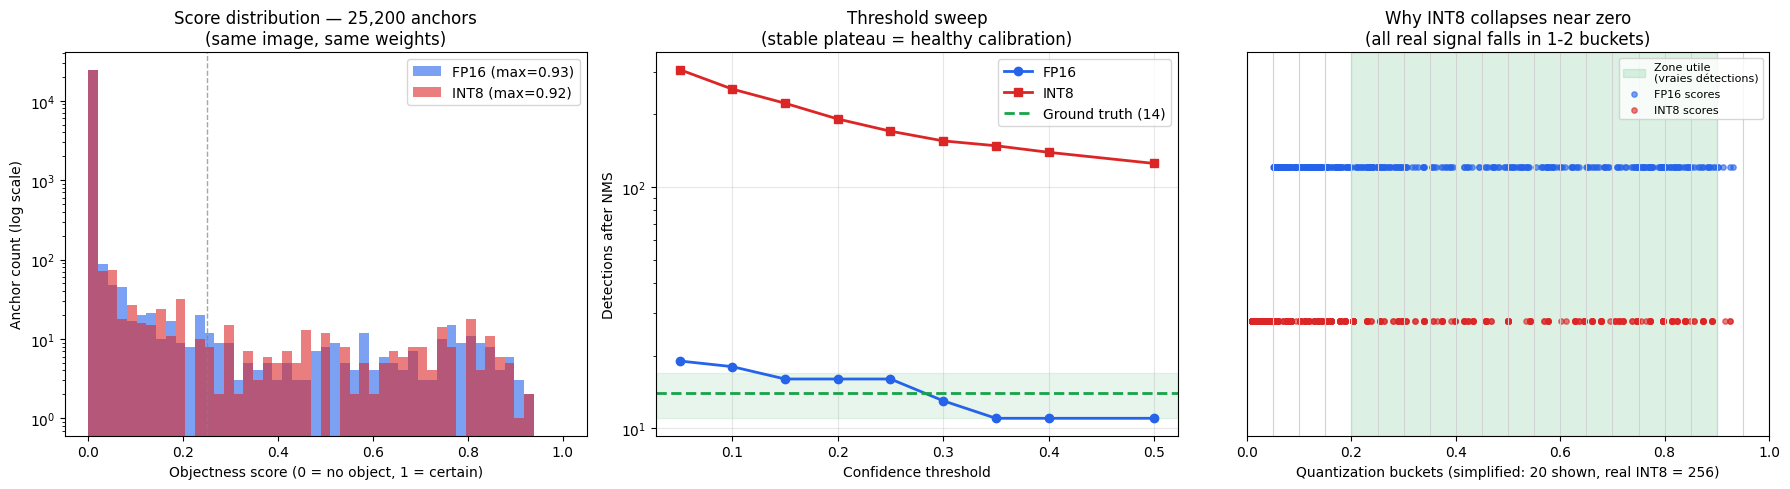

Saved: c:\Users\ASUS\Desktop\EdgeIA_PFE\plots\int8_vs_fp16_benchmark.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Score distribution histogram (log scale y-axis) ─────────────────
ax = axes[0]
bins = np.linspace(0, 1, 50)
ax.hist(scores_fp16, bins=bins, alpha=0.6, label=f'FP16 (max={max_obj_fp16:.2f})', color='#2563eb')
ax.hist(scores_int8, bins=bins, alpha=0.6, label=f'INT8 (max={max_obj_int8:.2f})', color='#dc2626')
ax.set_yscale('log')
ax.set_xlabel('Objectness score (0 = no object, 1 = certain)')
ax.set_ylabel('Anchor count (log scale)')
ax.set_title('Score distribution — 25,200 anchors\n(same image, same weights)')
ax.legend()
ax.axvline(0.25, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# ── Plot 2: Threshold sweep — detection count vs ground truth ───────────────
ax = axes[1]
ax.plot(sweep_thresholds, sweep_fp16, 'o-', color='#2563eb', label='FP16', linewidth=2, markersize=6)
ax.plot(sweep_thresholds, sweep_int8, 's-', color='#dc2626', label='INT8', linewidth=2, markersize=6)
ax.axhline(GROUND_TRUTH_PERSONS, color='#16a34a', linestyle='--', linewidth=2,
           label=f'Ground truth ({GROUND_TRUTH_PERSONS})')
ax.axhspan(GROUND_TRUTH_PERSONS-3, GROUND_TRUTH_PERSONS+3, color='#16a34a', alpha=0.1)
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Detections after NMS')
ax.set_title('Threshold sweep\n(stable plateau = healthy calibration)')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 3: The "shrinking ruler" analogy — quantization buckets ────────────
ax = axes[2]
n_buckets = 20   # simplified for visualization (real INT8 has 256)
bucket_edges = np.linspace(0, 1, n_buckets + 1)
decision_zone = (0.20, 0.90)   # where real detections actually live

for edge in bucket_edges:
    ax.axvline(edge, color='lightgray', linewidth=0.8)
ax.axvspan(*decision_zone, color='#16a34a', alpha=0.15, label='Zone utile\n(vraies détections)')
ax.scatter(scores_fp16[scores_fp16 > 0.05], np.full(len(scores_fp16[scores_fp16>0.05]), 0.7),
           color='#2563eb', s=15, alpha=0.6, label='FP16 scores')
ax.scatter(scores_int8[scores_int8 > 0.001], np.full(len(scores_int8[scores_int8>0.001]), 0.3),
           color='#dc2626', s=15, alpha=0.6, label='INT8 scores')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Quantization buckets (simplified: 20 shown, real INT8 = 256)')
ax.set_title('Why INT8 collapses near zero\n(all real signal falls in 1-2 buckets)')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
OUT_PATH = SAVE_PLOTS_DIR / 'int8_vs_fp16_benchmark.png'
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_PATH}')


#### Step 11: Reproducible figures - GT overlay & score histogram

- **Figure A** — ground truth boxes (green) vs INT8 predicted boxes (red)
  overlaid on the same image, at a low threshold (0.02) to show the raw
  candidate pool before any confidence filtering.
- **Figure B** — INT8 detections after NMS at a production threshold
  (0.30), shown next to the full score histogram for the same image, so
  the chosen threshold's position relative to the score distribution is
  visible at a glance.

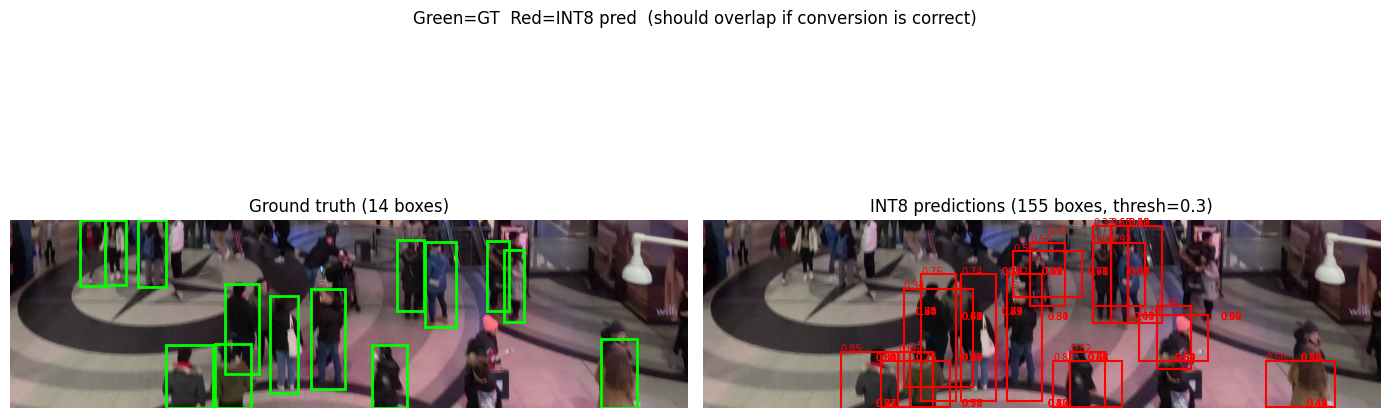

Saved: c:\Users\ASUS\Desktop\EdgeIA_PFE\plots\debug_coord_check.png
GT boxes : 14
INT8 boxes : 155  (thresh=0.3, after NMS)


In [13]:


FIG_THRESH_LOW = 0.3  # low threshold: shows raw candidate pool, pre-filtering

# Load ground truth for the benchmark image
LABELS_DIR  = TEST_IMGS_DIR.parent / 'labels'
lbl_path    = LABELS_DIR / (bench_sample.stem + '.txt')
gt          = np.loadtxt(str(lbl_path), ndmin=2).reshape(-1, 5)
img_w, img_h = img.size

# Convert GT normalised cxcywh -> pixel xyxy (original image space)
gt_xyxy_px = np.zeros((len(gt), 4))
gt_xyxy_px[:,0] = (gt[:,1] - gt[:,3]/2) * img_w
gt_xyxy_px[:,1] = (gt[:,2] - gt[:,4]/2) * img_h
gt_xyxy_px[:,2] = (gt[:,1] + gt[:,3]/2) * img_w
gt_xyxy_px[:,3] = (gt[:,2] + gt[:,4]/2) * img_h

# Run INT8 model at low threshold to get the raw candidate pool
interp_a = tf.lite.Interpreter(model_path=str(INT8_PATH))
interp_a.allocate_tensors()
inp_a = interp_a.get_input_details()[0]
out_a = interp_a.get_output_details()[0]
size_a = inp_a['shape'][1]

canvas_a, scale_a, px_a, py_a = letterbox_pil(img, size=size_a)
arr_a = (np.array(canvas_a, dtype=np.float32) / 255.0)[np.newaxis]
interp_a.set_tensor(inp_a['index'], arr_a)
interp_a.invoke()
preds_a = interp_a.get_tensor(out_a['index'])[0]

obj_a = preds_a[:, 4]
above_a = np.where(obj_a > FIG_THRESH_LOW)[0]

int8_xyxy_px = np.zeros((len(above_a), 4))
int8_scores  = obj_a[above_a]
for oi, i in enumerate(above_a):
    cx, cy, w, h = preds_a[i,0]*size_a, preds_a[i,1]*size_a, preds_a[i,2]*size_a, preds_a[i,3]*size_a
    int8_xyxy_px[oi] = [cx-w/2-px_a, cy-h/2-py_a, cx+w/2-px_a, cy+h/2-py_a]
    int8_xyxy_px[oi] /= scale_a

# Apply NMS so overlapping duplicates at this low threshold collapse
keep_a = greedy_nms(int8_xyxy_px, int8_scores, iou_thresh=0.45)
int8_xyxy_px = int8_xyxy_px[keep_a]
int8_scores  = int8_scores[keep_a]

# ── Plot: GT (left) vs INT8 (right) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Green=GT  Red=INT8 pred  (should overlap if conversion is correct)')

axes[0].imshow(img)
for box in gt_xyxy_px:
    x1, y1, x2, y2 = box
    axes[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                       linewidth=2, edgecolor='lime', facecolor='none'))
axes[0].set_title(f'Ground truth ({len(gt_xyxy_px)} boxes)')
axes[0].axis('off')

axes[1].imshow(img)
for box, score in zip(int8_xyxy_px, int8_scores):
    x1, y1, x2, y2 = box
    axes[1].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                       linewidth=1.5, edgecolor='red', facecolor='none'))
    axes[1].text(x1, max(y1-3,0), f'{score:.2f}', color='red', fontsize=7)
axes[1].set_title(f'INT8 predictions ({len(int8_xyxy_px)} boxes, thresh={FIG_THRESH_LOW})')
axes[1].axis('off')

plt.tight_layout()
fig_a_path = SAVE_PLOTS_DIR / 'debug_coord_check.png'
plt.savefig(fig_a_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_a_path}')
print(f'GT boxes : {len(gt_xyxy_px)}')
print(f'INT8 boxes : {len(int8_xyxy_px)}  (thresh={FIG_THRESH_LOW}, after NMS)')


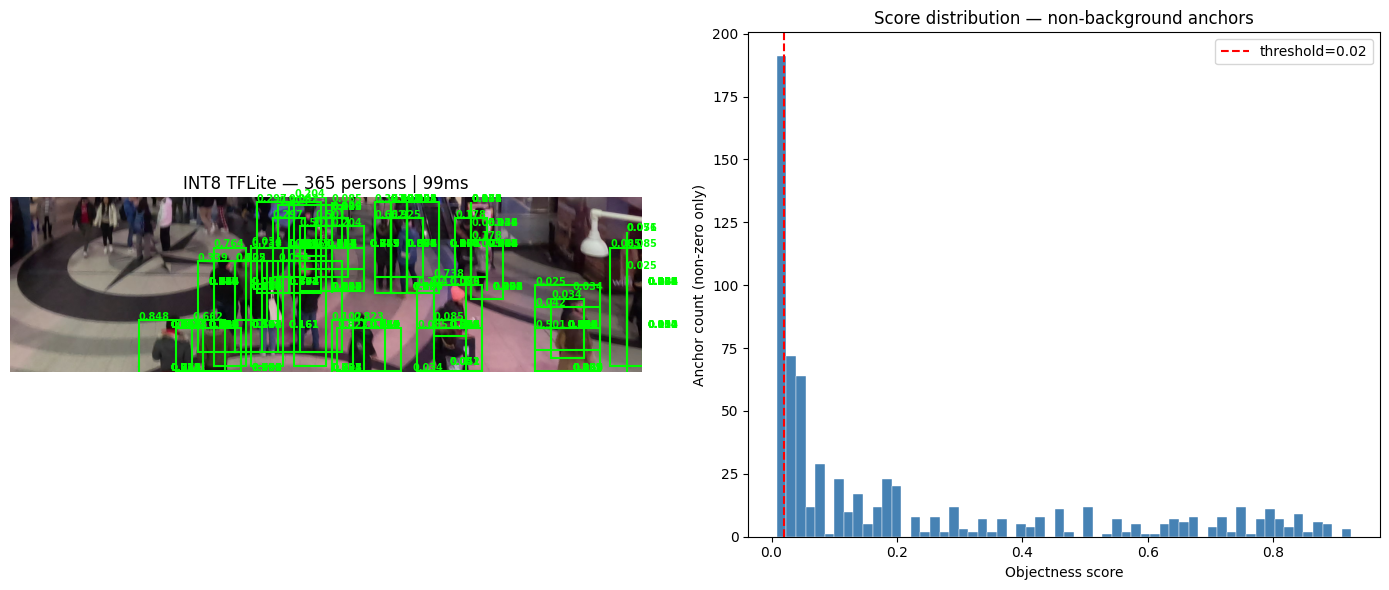

Saved: c:\Users\ASUS\Desktop\EdgeIA_PFE\plots\sample_int8_detection.png
Detections @ thresh=0.02: 365  (ground truth: 14)
Latency: 99.0 ms


In [14]:
FIG_THRESH_PROD = 0.02   # production threshold

# Re-run INT8 at the production threshold for the detection panel
above_b = np.where(obj_a > FIG_THRESH_PROD)[0]
int8_xyxy_b = np.zeros((len(above_b), 4))
int8_scores_b = obj_a[above_b]
for oi, i in enumerate(above_b):
    cx, cy, w, h = preds_a[i,0]*size_a, preds_a[i,1]*size_a, preds_a[i,2]*size_a, preds_a[i,3]*size_a
    int8_xyxy_b[oi] = [cx-w/2-px_a, cy-h/2-py_a, cx+w/2-px_a, cy+h/2-py_a]
    int8_xyxy_b[oi] /= scale_a

keep_b = greedy_nms(int8_xyxy_b, int8_scores_b, iou_thresh=0.45)
int8_xyxy_b = int8_xyxy_b[keep_b]
int8_scores_b = int8_scores_b[keep_b]

import time as _time
t0 = _time.time()
interp_a.invoke()
latency_ms = (_time.time() - t0) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img)
for box, score in zip(int8_xyxy_b, int8_scores_b):
    x1, y1, x2, y2 = box
    axes[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                       linewidth=1.5, edgecolor='lime', facecolor='none'))
    axes[0].text(x1, max(y1-3,0), f'{score:.3f}', color='lime', fontsize=7, fontweight='bold')
axes[0].set_title(f'INT8 TFLite — {len(int8_xyxy_b)} persons | {latency_ms:.0f}ms')
axes[0].axis('off')

nonzero_scores = obj_a[obj_a > 0.001]
axes[1].hist(nonzero_scores, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(FIG_THRESH_PROD, color='red', linestyle='--', label=f'threshold={FIG_THRESH_PROD}')
axes[1].set_xlabel('Objectness score')
axes[1].set_ylabel('Anchor count (non-zero only)')
axes[1].set_title('Score distribution — non-background anchors')
axes[1].legend()

plt.tight_layout()
fig_b_path = SAVE_PLOTS_DIR / 'sample_int8_detection.png'
plt.savefig(fig_b_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_b_path}')
print(f'Detections @ thresh={FIG_THRESH_PROD}: {len(int8_xyxy_b)}  (ground truth: {GROUND_TRUTH_PERSONS})')
print(f'Latency: {latency_ms:.1f} ms')
